---
title: "Standard SVGP"
---

# Standard SVGP with pyrox

The first notebook in the pyrox SVGP trilogy: a textbook **stochastic variational GP** with $M$ inducing points living in the input space. Everything here is the reference that the next two notebooks will bend — notebook 2 replaces the inducing points with a spherical-harmonic basis, notebook 3 warps the input space through a small neural network before the kernel sees it.

The goal for *this* notebook is narrow: set up the pyrox + optax scaffold that the later variants will reuse, and produce the canonical sanity-check plots — a monotone decreasing loss curve, inducing points migrating toward informative regions of the input, and a posterior mean + $2\sigma$ band that collapses onto the training data and widens over the input gap.

## Background

### Why sparse?

The exact GP posterior at $N$ training points and $N_*$ test points costs $\mathcal{O}(N^3)$ once and $\mathcal{O}(N^2 N_*)$ per prediction — the bottleneck being the solve against $K_{XX} + \sigma^2 I$. With $N$ in the thousands this is already uncomfortable; with $N$ in the hundreds of thousands it is impossible on a single device. **Sparse variational GPs** (Titsias 2009, Hensman et al. 2013, 2015) replace the data-sized Gram matrix by a small $M \times M$ system over $M$ *inducing values* $u = f(Z)$ at user-chosen inducing inputs $Z \in \mathbb{R}^{M \times D}$, with $M \ll N$.

### The ELBO

A variational posterior $q(u) = \mathcal{N}(m, S)$ induces a marginal Gaussian over the latent function at any input through the prior conditional $p(f \mid u)$. The resulting variational lower bound on the log marginal likelihood is

$$\mathcal{L} = \sum_{n=1}^{N} \mathbb{E}_{q(f_n)}\!\bigl[\log p(y_n \mid f_n)\bigr] \;-\; \mathrm{KL}\!\bigl(q(u)\,\|\,p(u)\bigr),$$

with $p(u) = \mathcal{N}(0, K_{ZZ} + \text{jitter}\,I)$. For Gaussian observation noise the expected log-likelihood has a closed form, so the ELBO is *analytic* and cheap to differentiate through — exactly the path [`pyrox.gp.svgp_elbo`](https://github.com/jejjohnson/pyrox/blob/main/src/pyrox/gp/_inference.py) exposes.

### The whitened parameterisation

Raw $q(u)$ couples the variational mean/covariance to the kernel through $K_{ZZ}$ — the loss landscape tilts as hyperparameters move. Hensman-et-al-2015 reparameterise in whitened coordinates $v$ with $u = L_{ZZ}\, v$, $L_{ZZ} = \mathrm{chol}(K_{ZZ} + \text{jitter}\,I)$, so the prior over $v$ is $\mathcal{N}(0, I)$ and the KL term decouples from the kernel. This is `pyrox.gp.WhitenedGuide` and it is the only guide that is both cheap and numerically robust for gradient-based training — we use it throughout the trilogy.

## Setup

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import optax
from jaxtyping import Array, Float

from pyrox.gp import (
    GaussianLikelihood,
    Kernel,
    SparseGPPrior,
    WhitenedGuide,
    svgp_elbo,
)
from pyrox.gp._src.kernels import rbf_kernel

jax.config.update("jax_enable_x64", True)

/anaconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Toy data

A noisy 1-D sine with an extinction gap in the middle — $N = 500$ training points spread either side of the gap. The gap is the cheap sanity check: any well-fit GP should show a posterior band that narrows on the data and widens visibly where it has none.

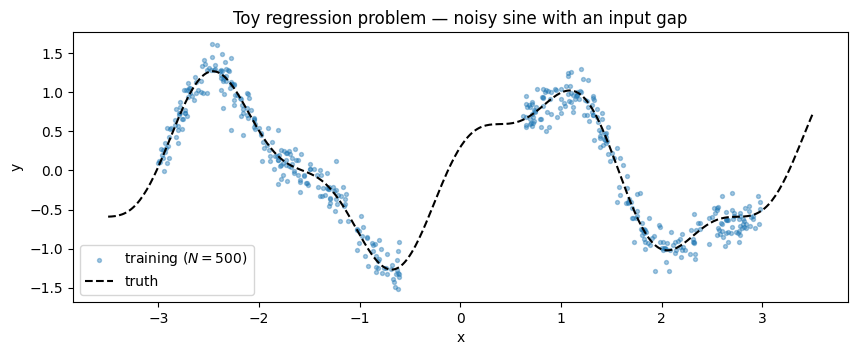

In [2]:
key = jr.PRNGKey(0)
key, key_noise = jr.split(key)


def f_true(x: Float[Array, " N"]) -> Float[Array, " N"]:
    return jnp.sin(2.0 * x) + 0.3 * jnp.cos(5.0 * x)


N = 500
X_left = jr.uniform(jr.PRNGKey(1), (N // 2, 1), minval=-3.0, maxval=-0.6)
X_right = jr.uniform(jr.PRNGKey(2), (N // 2, 1), minval=0.6, maxval=3.0)
X_train = jnp.concatenate([X_left, X_right], axis=0)
noise_std = 0.15
y_train = f_true(X_train.squeeze(-1)) + noise_std * jr.normal(key_noise, (N,))
X_test = jnp.linspace(-3.5, 3.5, 400).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.scatter(X_train.squeeze(-1), y_train, s=8, alpha=0.4, label=f"training ($N={N}$)")
ax.plot(X_test.squeeze(-1), f_true(X_test.squeeze(-1)), "k--", lw=1.5, label="truth")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Toy regression problem — noisy sine with an input gap")
ax.legend(loc="lower left")
plt.show()

## Kernel

The SVGP ELBO is a pure JAX function, so to train hyperparameters via `optax` we need the kernel to expose its scalars as `equinox.Module` array leaves — not hidden in the `pyrox.Parameterized` registry. Pattern A from [`exact_gp_regression.ipynb`](../../../notebooks/pyrox/gp/exact_gp_regression.ipynb) is the right tool: subclass the `Kernel` protocol with a plain equinox module and store unconstrained scalars on the log scale (so `exp` handles the positivity constraint for free).

In [3]:
class RBFLite(Kernel, eqx.Module):
    """Pure-equinox RBF — trainable log-variance / log-lengthscale scalars."""

    log_variance: Float[Array, ""]
    log_lengthscale: Float[Array, ""]

    @classmethod
    def init(cls, variance: float = 1.0, lengthscale: float = 1.0) -> "RBFLite":
        return cls(
            log_variance=jnp.log(jnp.asarray(variance)),
            log_lengthscale=jnp.log(jnp.asarray(lengthscale)),
        )

    @property
    def variance(self) -> Float[Array, ""]:
        return jnp.exp(self.log_variance)

    @property
    def lengthscale(self) -> Float[Array, ""]:
        return jnp.exp(self.log_lengthscale)

    def __call__(
        self,
        X1: Float[Array, "N1 D"],
        X2: Float[Array, "N2 D"],
    ) -> Float[Array, "N1 N2"]:
        return rbf_kernel(X1, X2, self.variance, self.lengthscale)

    def diag(self, X: Float[Array, "N D"]) -> Float[Array, " N"]:
        return self.variance * jnp.ones(X.shape[0], dtype=X.dtype)

The likelihood is `GaussianLikelihood` from pyrox — one field `noise_var`. Training `noise_var` directly would require a positivity projection; shipping a one-field wrapper that stores `log_noise_var` avoids the bookkeeping.

In [4]:
class TrainableGaussianLikelihood(eqx.Module):
    """Log-parameterised Gaussian likelihood; `.materialise()` returns the pyrox one."""

    log_noise_var: Float[Array, ""]

    @classmethod
    def init(cls, noise_var: float = 0.1) -> "TrainableGaussianLikelihood":
        return cls(log_noise_var=jnp.log(jnp.asarray(noise_var)))

    def materialise(self) -> GaussianLikelihood:
        return GaussianLikelihood(noise_var=jnp.exp(self.log_noise_var))

## Model

$M = 20$ inducing points — placed by a Latin-style random sweep across the input range so they cover both data lobes *and* the gap. The gap locations will move toward the lobes during training; that migration is the headline visual of the notebook.

In [5]:
M = 20
key, key_z = jr.split(key)
Z_init = jr.uniform(key_z, (M, 1), minval=-3.0, maxval=3.0)

prior = SparseGPPrior(
    kernel=RBFLite.init(variance=1.0, lengthscale=0.6),
    Z=Z_init,
    jitter=1e-4,
)
guide = WhitenedGuide.init(num_inducing=M)
lik_w = TrainableGaussianLikelihood.init(noise_var=noise_std**2)

## Training loop

`svgp_elbo` is a scalar JAX function of `(prior, guide, lik, X, y)` — put all three modules into a tuple, take `eqx.filter_value_and_grad` of the negative ELBO, and let `optax.adam` drive the leaves. Only array leaves get gradients; the rest of each module (the `solver` field, callbacks, etc.) is left alone.

In [6]:
Params = tuple  # alias: (prior, guide, lik_wrapper)


def neg_elbo(params: Params, X: Float[Array, "N D"], y: Float[Array, " N"]) -> Float[Array, ""]:
    prior_p, guide_p, lik_p = params
    lik = lik_p.materialise()
    return -svgp_elbo(prior_p, guide_p, lik, X, y)


@eqx.filter_jit
def step(
    params: Params,
    opt_state: optax.OptState,
    X: Float[Array, "N D"],
    y: Float[Array, " N"],
) -> tuple[Params, optax.OptState, Float[Array, ""]]:
    loss, grads = eqx.filter_value_and_grad(neg_elbo)(params, X, y)
    updates, opt_state = optimiser.update(grads, opt_state, params)
    params = eqx.apply_updates(params, updates)
    return params, opt_state, loss


params = (prior, guide, lik_w)
optimiser = optax.adam(5e-2)
opt_state = optimiser.init(eqx.filter(params, eqx.is_inexact_array))

Z_before = params[0].Z.copy()
n_steps = 800
losses: list[float] = []
for i in range(n_steps):
    params, opt_state, loss = step(params, opt_state, X_train, y_train)
    losses.append(float(loss))

prior_fit, guide_fit, lik_wrap_fit = params
Z_after = prior_fit.Z

print(f"final  -ELBO          = {losses[-1]:.3f}")
print(f"fitted variance       = {float(prior_fit.kernel.variance):.3f}")
print(f"fitted lengthscale    = {float(prior_fit.kernel.lengthscale):.3f}")
print(f"fitted noise std      = {float(jnp.exp(0.5 * lik_wrap_fit.log_noise_var)):.3f}  (truth {noise_std})")

final  -ELBO          = -193.226
fitted variance       = 0.559
fitted lengthscale    = 0.515
fitted noise std      = 0.154  (truth 0.15)


### Loss curve

The first ~50 steps swallow almost all of the loss drop — the remaining 700 steps fine-tune kernel hyperparameters and inducing positions through a shallow tail. A `symlog` y-axis keeps both phases readable on one plot.

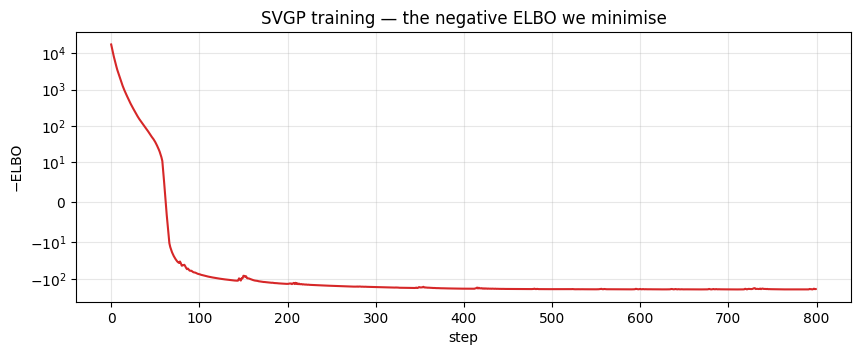

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(losses, color="C3", lw=1.5)
ax.set_xlabel("step")
ax.set_ylabel("−ELBO")
ax.set_yscale("symlog", linthresh=10.0)
ax.set_title("SVGP training — the negative ELBO we minimise")
ax.grid(alpha=0.3, which="both")
plt.show()

### Inducing-point migration

Snapshot of the inducing inputs at step 0 (random initialisation) and at the end of training. A well-fit SVGP drags inducing points toward regions where they reduce the ELBO most — typically toward data-rich areas where the posterior wants sharp resolution. Expect the gap to be sparsely populated and the two data lobes to be denser.

**A visible artefact.** The ELBO penalises sloppy coverage but does *not* penalise two inducing points landing on top of each other — the KL term handles that degeneracy silently via a correlated `q(u)`. You'll often see small pile-ups (e.g. two points coincident around `x ≈ 1.4` in the fitted row below). Fixing it properly takes either a repulsive regulariser on `Z` or a different inducing parameterisation — exactly the door that notebook 2 opens with spherical-harmonic features, where "inducing points" become a fixed orthogonal basis and the pile-up failure mode can't exist.

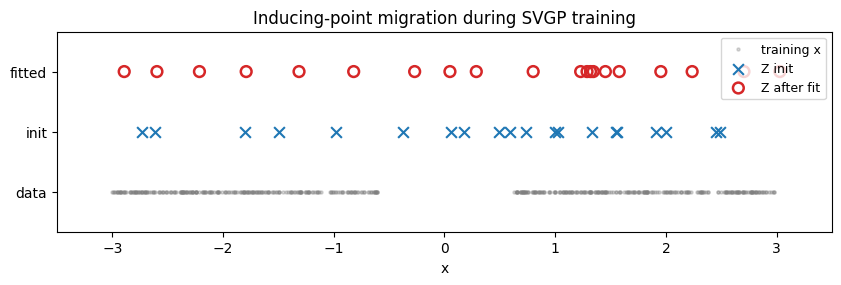

In [8]:
fig, ax = plt.subplots(figsize=(10, 2.6))
ax.scatter(X_train.squeeze(-1), jnp.full_like(X_train.squeeze(-1), 0.2), s=5, alpha=0.3, color="gray", label="training x")
ax.scatter(Z_before.squeeze(-1), jnp.full((M,), 0.5), s=60, marker="x", color="C0", label="Z init", zorder=4)
ax.scatter(Z_after.squeeze(-1), jnp.full((M,), 0.8), s=60, marker="o", facecolors="none", edgecolors="C3", linewidths=1.8, label="Z after fit", zorder=5)
ax.set_yticks([0.2, 0.5, 0.8])
ax.set_yticklabels(["data", "init", "fitted"])
ax.set_xlabel("x")
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(0, 1.0)
ax.set_title("Inducing-point migration during SVGP training")
ax.legend(loc="upper right", fontsize=9)
plt.show()

### Posterior predictive

`pyrox.gp.WhitenedGuide.predict(K_xz, K_zz_op, K_xx_diag)` returns posterior mean and variance at any test set given the three predictive blocks from the sparse prior. Add the prior's mean function (zero here) back on, then overlay the $\pm 2\sigma$ band on top of the training scatter.

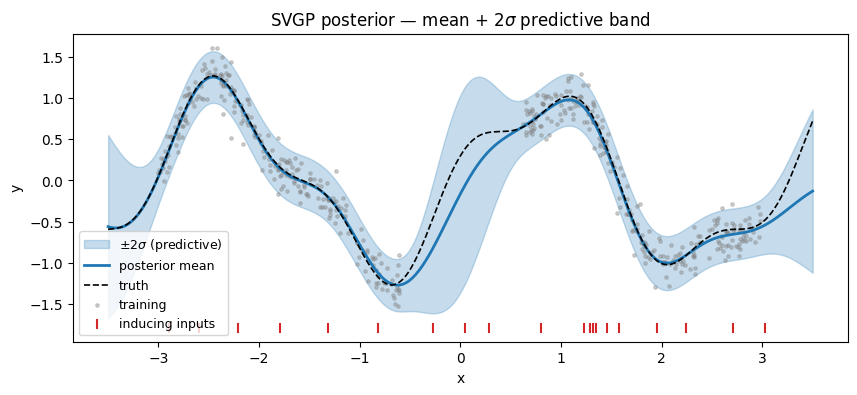

In [9]:
K_zz_op, K_xz, K_xx_diag = prior_fit.predictive_blocks(X_test)
f_loc, f_var = guide_fit.predict(K_xz, K_zz_op, K_xx_diag)
f_loc = f_loc + prior_fit.mean(X_test)
noise_var_fit = jnp.exp(lik_wrap_fit.log_noise_var)
y_std = jnp.sqrt(f_var + noise_var_fit)

fig, ax = plt.subplots(figsize=(10, 4.0))
ax.fill_between(
    X_test.squeeze(-1),
    f_loc - 2 * y_std,
    f_loc + 2 * y_std,
    alpha=0.25,
    color="C0",
    label=r"$\pm 2\sigma$ (predictive)",
)
ax.plot(X_test.squeeze(-1), f_loc, "C0-", lw=2, label="posterior mean")
ax.plot(X_test.squeeze(-1), f_true(X_test.squeeze(-1)), "k--", lw=1.2, label="truth")
ax.scatter(X_train.squeeze(-1), y_train, s=6, alpha=0.35, color="gray", label="training")
ax.scatter(
    Z_after.squeeze(-1),
    jnp.full((M,), ax.get_ylim()[0] + 0.05),
    s=50,
    marker="|",
    color="C3",
    label="inducing inputs",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("SVGP posterior — mean + $2\\sigma$ predictive band")
ax.legend(loc="lower left", fontsize=9)
plt.show()

**A note on the gap.** The posterior mean is smoother across the input gap than the truth (the true function has a local min near `x ≈ -0.3` that the blue mean rounds off). This is not a bug — with only $M = 20$ inducing points and a lengthscale fit at $\ell \approx 0.5$ against a gap about 1.2 units wide, the model has no data *and* limited inducing density there, so the posterior relaxes toward the prior (zero-mean, wide band). Widening the band is the epistemically correct response; getting the mean exactly right over the gap would require either more inducing capacity or a stronger structural prior (e.g. periodic kernel).

## Summary

- `SparseGPPrior(kernel, Z)` + `WhitenedGuide` + `GaussianLikelihood` is the canonical SVGP triple.
- `svgp_elbo` is a pure JAX scalar so optax + `eqx.filter_value_and_grad` trains everything jointly (kernel hyperparameters, inducing inputs, guide parameters, noise).
- The fitted lengthscale and noise should be close to the true generating values; inducing points migrate toward data lobes.

**Next:** notebook 2 replaces $Z \in \mathbb{R}^{M \times D}$ with a spherical-harmonic basis `SphericalHarmonicInducingFeatures.init(l_max=8)` — same ELBO, same training loop, but the `M \times M` solve collapses to an elementwise division thanks to Funk–Hecke diagonality.